In [5]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, LSTM, Dropout

In [6]:
dataset_path = "/kaggle/input/datasets/chethuhn/network-intrusion-dataset"

In [7]:
files = os.listdir(dataset_path)

print("Dataset Files:")
for f in files:
    print(f)

Dataset Files:
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [8]:
dataframes = []

for file in files:
    
    if file.endswith(".csv"):
        
        file_path = os.path.join(dataset_path, file)
        
        print("Loading:", file)
        
        df = pd.read_csv(file_path, low_memory=False)
        
        dataframes.append(df)

data = pd.concat(dataframes, ignore_index=True)

print("Combined dataset shape:", data.shape)

Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Combined dataset shape: (2830743, 79)


In [9]:
data.columns = data.columns.str.strip()

In [10]:
data.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [7]:
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [11]:
data['Label'].value_counts()

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [12]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)

data.dropna(inplace=True)

In [13]:
data.isnull().sum().sum()

np.int64(0)

In [14]:
X = data.drop("Label", axis=1)

y = data["Label"]

In [15]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [16]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2262300, 78)
Test shape: (565576, 78)


In [18]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
y_pred = rf_model.predict(X_test)

In [20]:
rf_accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", rf_accuracy)

print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.998675686379903
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    453899
           1       0.86      0.75      0.80       383
           2       1.00      1.00      1.00     25749
           3       1.00      1.00      1.00      2055
           4       1.00      1.00      1.00     46259
           5       0.99      0.99      0.99      1103
           6       0.99      1.00      1.00      1146
           7       1.00      1.00      1.00      1614
           8       1.00      1.00      1.00         3
           9       1.00      0.60      0.75         5
          10       0.99      1.00      1.00     31769
          11       1.00      1.00      1.00      1181
          12       0.72      0.82      0.77       265
          13       0.00      0.00      0.00         1
          14       0.55      0.36      0.44       144

    accuracy                           1.00    565576
   macro avg       0.87      0.83     

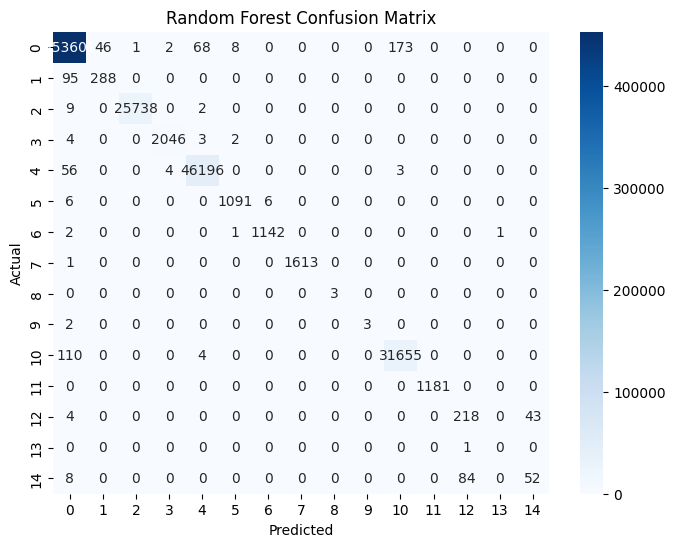

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
X_train_dl = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

X_test_dl = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [23]:
model = Sequential()

model.add(Conv1D(
    filters=64,
    kernel_size=3,
    activation='relu',
    input_shape=(X_train_dl.shape[1],1)
))

model.add(MaxPooling1D(pool_size=2))

model.add(LSTM(64))

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(len(np.unique(y)), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-10 05:16:16.924701: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train_dl,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 884s 31ms/step - accuracy: 0.9340 - loss: 0.2359 - val_accuracy: 0.9749 - val_loss: 0.0572
Epoch 2/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 879s 31ms/step - accuracy: 0.9766 - loss: 0.0573 - val_accuracy: 0.9803 - val_loss: 0.0489
Epoch 3/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 874s 31ms/step - accuracy: 0.9807 - loss: 0.0476 - val_accuracy: 0.9760 - val_loss: 0.0512
Epoch 4/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 875s 31ms/step - accuracy: 0.9820 - loss: 0.0437 - val_accuracy: 0.9836 - val_loss: 0.0382
Epoch 5/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 860s 30ms/step - accuracy: 0.9827 - loss: 0.0425 - val_accuracy: 0.9848 - val_loss: 0.0371
Epoch 6/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 854s 30ms/step - accuracy: 0.9845 - loss: 0.0391 - val_accuracy: 0.9816 - val_loss: 0.0445
Epoch 7/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 852s 30ms/step - accuracy: 0.9849 - loss: 0.0380 - val_accuracy: 0.9865 - val_loss: 0.0346
Epoch 8/10
28279/28279 ━━━━━━━━━━━━━━━━━━━━ 851s 30ms/s

In [26]:
loss, cnn_lstm_accuracy = model.evaluate(X_test_dl, y_test)

print("CNN-LSTM Accuracy:", cnn_lstm_accuracy)

17675/17675 ━━━━━━━━━━━━━━━━━━━━ 178s 10ms/step - accuracy: 0.9867 - loss: 0.0327
CNN-LSTM Accuracy: 0.9868505597114563


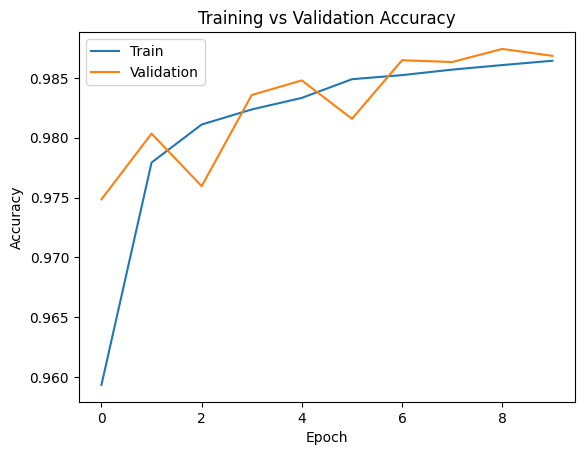

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

In [28]:
comparison = pd.DataFrame({

    "Model": ["Random Forest", "CNN-LSTM"],

    "Accuracy": [rf_accuracy, cnn_lstm_accuracy]

})

comparison

,Model,Accuracy
0,Random Forest,0.998676
1,CNN-LSTM,0.986851


In [29]:
import joblib

joblib.dump(rf_model, "random_forest_ids_model.pkl")

model.save("cnn_lstm_ids_model.h5")